# Randomized Pivoted Cholesky

In [30]:
import numpy as np

def rpcholesky(A, k):
    """
    RPCholesky algorithm for Nyström approximation of a PSD matrix.

    Parameters:
    A : numpy.ndarray
        Input PSD matrix (real or complex Hermitian) of shape (N, N).
    k : int
        Approximation rank (number of pivots).

    Returns:
    S : list of int
        List of selected pivot indices.
    F : numpy.ndarray
        Matrix of shape (N, k) such that F @ F.conj().T is the Nyström approximation.
    """
    N = A.shape[0]
    F = np.zeros((N, k), dtype=np.complex128)  # Use complex dtype to handle both cases
    d = np.diag(A).real.copy()  # Diagonal is real for PSD matrices
    S = []
    for i in range(k):
        # Check if residual diagonal has non-zero sum
        total = np.sum(d)
        if np.max(d) <= 1e-14:  # Early stop if residual is negligible
            break
        # Sample pivot with probability proportional to d
        prob = d / total
        s_i = np.random.choice(N, p=prob)
        S.append(s_i)
        # Normalize by sqrt(g[s_i]) and handle potential division by zero
        g_si = d[s_i]  # Must be real and non-negative for PSD
        if g_si <= 0 :
            print(len(S))
            print(g_si)
            raise ValueError("Diagonal entry is non-positive, numerical error detected.")
        #if g_si < 10e-14 :
        #    i-=1
        #    print('error')
        #    continue
        #Compute the selected column of A and subtract previous projections
        g = A[:, s_i].astype(np.complex128)
        if i > 0:
            proj = F[:, :i] @ F[s_i, :i].conj().T
            g -= proj

        
            
        F[:, i] = g / np.sqrt(g_si)

        # Update the residual diagonal and ensure non-negativity
        d -= np.abs(F[:, i])**2
        d = np.maximum(d, 0)
    return S, F



# Test Example with Diagonal Matrix and Random PSD Matrix

In [2]:
# Test 1: Diagonal matrix with known structure
def test_diagonal_case():
    np.random.seed(42)  # For reproducibility
    N = 9
    diag_entries = np.array([6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.1, 0.05, 0.03])
    A = np.diag(diag_entries)  # Diagonal PSD matrix
    k = 6
    
    # Run RPCholesky
    S, F = rpcholesky(A, k)
    F = F.astype(np.float64)  # Ensure real output for diagonal case
    A_hat = F @ F.T
    
    # Compute relative trace error
    error_trace = np.trace(A - A_hat)
    rel_error = error_trace / np.trace(A)
    print(f"Test 1 (Diagonal Matrix):")
    print(f"  Selected pivots: {S}")
    print(f"  Relative trace error: {rel_error:.4f}\n")

# Test 2: Random PSD matrix
def test_random_psd_case():
    np.random.seed(42)
    N = 1000
    rank = 70  # Rank of the underlying matrix
    X = np.random.randn(N, rank)
    A = X @ X.T  # Construct a low-rank PSD matrix
    k = 66
    
    # Run RPCholesky
    S, F = rpcholesky(A, k)
    A_hat = F @ F.T
    
    # Compute relative trace error
    error_trace = np.trace(A - A_hat)
    rel_error = error_trace / np.trace(A)
    print(f"Test 2 (Random Low-Rank PSD Matrix):")
    print(f"  Relative trace error: {rel_error:.4f}")

# Run tests
test_diagonal_case()
test_random_psd_case()

Test 1 (Diagonal Matrix):
  Selected pivots: [1, 5, 3, 2, 0, 4]
  Relative trace error: 0.0085

Test 2 (Random Low-Rank PSD Matrix):
  Relative trace error: 0.0524+0.0000j


/var/folders/l6/yxg8ghhx09s1c_004vgq6wvr0000gn/T/ipykernel_7758/1883851399.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  F = F.astype(np.float64)  # Ensure real output for diagonal case


# Greedy Pivoting

In [31]:
import numpy as np

def greedy_pivoted_cholesky(A, k):
    """
    Greedy pivoted Cholesky decomposition for Nyström approximation.

    Parameters:
    A : numpy.ndarray
        Input PSD matrix (real or complex Hermitian) of shape (N, N).
    k : int
        Approximation rank (number of pivots).

    Returns:
    S : list of int
        List of selected pivot indices.
    F : numpy.ndarray
        Matrix of shape (N, k) such that F @ F.conj().T is the Nyström approximation.
    """
    N = A.shape[0]
    F = np.zeros((N, k), dtype=np.complex128)
    d = np.diag(A).real.copy()  # Diagonal is real for PSD matrices
    S = []

    for i in range(k):   
        if np.max(d) <= 1e-14:  # Early stop if residual is negligible
            break
        # Select pivot with largest diagonal entry
        s_i = np.argmax(d)
        S.append(s_i)
                 # Normalize and handle numerical issues
        g_si =d[s_i]
       # if g_si < 10e-14 :
       #     i-=1
       #     continue
        if g_si <= 0 :
           print(len(S))
           print(g_si)
           raise ValueError("Diagonal entry is non-positive, numerical error detected.")
        

        # Compute column and subtract previous projections
        g = A[:, s_i].astype(np.complex128)
        if i > 0:
            proj = F[:, :i] @ F[s_i, :i].conj().T
            g -= proj

    
        F[:, i] = g / np.sqrt(g_si)

        # Update residual diagonal
        d -= np.abs(F[:, i])**2
        d = np.maximum(d, 0)
    return S, F


# Uniform Pivoting

In [32]:

def uniform_pivoted_cholesky(A, k):
    """
    Uniform random pivoted Cholesky decomposition for Nyström approximation (without replacement).

    Parameters:
    A : numpy.ndarray
        Input PSD matrix (real or complex Hermitian) of shape (N, N).
    k : int
        Approximation rank (number of pivots), must be <= N.

    Returns:
    S : list of int
        List of selected pivot indices.
    F : numpy.ndarray
        Matrix of shape (N, k) such that F @ F.conj().T is the Nyström approximation.
    """
    N = A.shape[0]
    if k > N:
        raise ValueError("k must be less than or equal to N when sampling without replacement.")

    F = np.zeros((N, k), dtype=np.complex128)
    d = np.diag(A).real.copy()
    S = []
    unchosen = list(range(N))

    for i in range(k):
        # Randomly sample one index without replacement
        s_i = np.random.choice(unchosen)
        unchosen.remove(s_i)
        S.append(s_i)

        g_si = d[s_i]
        if g_si < 1e-14:
            # If pivot is numerically zero, skip this iteration
            continue

        g = A[:, s_i].astype(np.complex128)

        if i > 0:
            proj = F[:, :i] @ F[s_i, :i].conj().T
            g -= proj

        F[:, i] = g / np.sqrt(g_si)

        # Update diagonal residuals
        d -= np.abs(F[:, i])**2
        d = np.maximum(d, 0)

    return S, F


 




# Test for Uniform and Greedy Pivoting

In [5]:
def test_greedy_and_uniform():
    np.random.seed(42)

    # Test 1: Diagonal matrix
    N = 9
    A = np.diag([6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.1, 0.05, 0.03])
    k = 8

    # Greedy pivoting
    S_greedy, F_greedy = greedy_pivoted_cholesky(A, k)
    A_hat_greedy = F_greedy @ F_greedy.T.conj()
    error_greedy = np.trace(A - A_hat_greedy) / np.trace(A)

    # Uniform pivoting
    S_uniform, F_uniform = uniform_pivoted_cholesky(A, k)
    A_hat_uniform = F_uniform @ F_uniform.T.conj()
    error_uniform = np.trace(A - A_hat_uniform) / np.trace(A)

    print("Test 1 (Diagonal Matrix):")
    print(f"  Greedy pivots: {S_greedy} | Relative trace error: {error_greedy:.4f}")
    print(f"  Uniform pivots: {S_uniform} | Relative trace error: {error_uniform:.4f}\n")

    # Test 2: Random low-rank PSD matrix
    N = 100
    rank = 20
    X = np.random.randn(N, rank)
    A = X @ X.T
    k = 18

    # Greedy pivoting
    _, F_greedy = greedy_pivoted_cholesky(A, k)
    A_hat_greedy = F_greedy @ F_greedy.T.conj()
    error_greedy = np.trace(A - A_hat_greedy) / np.trace(A)

    # Uniform pivoting
    _, F_uniform = uniform_pivoted_cholesky(A, k)
    A_hat_uniform = F_uniform @ F_uniform.T.conj()
    error_uniform = np.trace(A - A_hat_uniform) / np.trace(A)

    print("Test 2 (Random Low-Rank PSD Matrix):")
    print(f"  Greedy relative trace error: {error_greedy:.4f}")
    print(f"  Uniform relative trace error: {error_uniform:.4f}")

test_greedy_and_uniform()

Test 1 (Diagonal Matrix):
  Greedy pivots: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)] | Relative trace error: 0.0014+0.0000j
  Uniform pivots: [np.int64(6), np.int64(3), np.int64(5), np.int64(2), np.int64(8), np.int64(0), np.int64(7), np.int64(4)] | Relative trace error: 0.2361+0.0000j

Test 2 (Random Low-Rank PSD Matrix):
  Greedy relative trace error: 0.0635+0.0000j
  Uniform relative trace error: 0.0827+0.0000j


# Numerical Test Example with Artificial Data

Testing on Smile Dataset (σ = 2.0):
  RPCholesky: Relative Trace Error = 6.0638e-14
  Greedy: Relative Trace Error = 1.2566e-15
  Uniform: Relative Trace Error = 4.0745e-03

Testing on Spiral Dataset (σ = 1000):
  RPCholesky: Relative Trace Error = 3.9806e-01
  Greedy: Relative Trace Error = 8.8965e-01
  Uniform: Relative Trace Error = 4.0872e-01


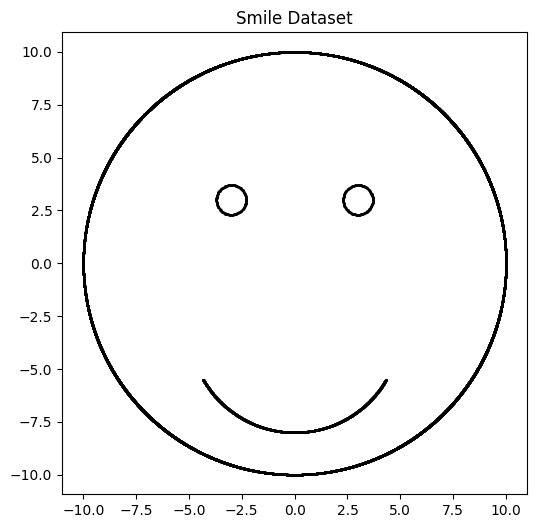

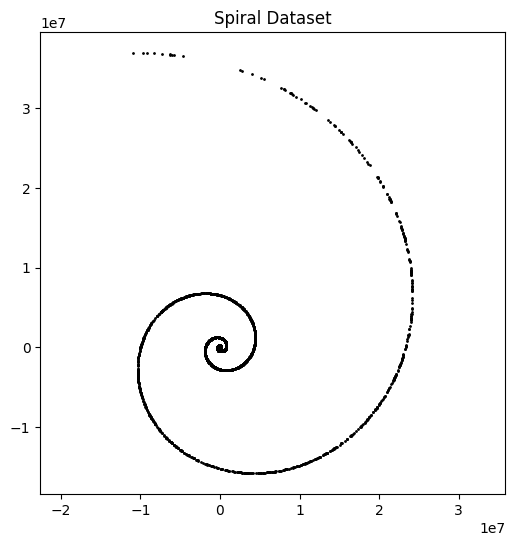

In [37]:
import matplotlib.pyplot as plt

# =============================================
# 1. Dataset Generation
# =============================================


def generate_smile(N_face=9000, N_mouth=900, N_eye=100):
    """Generate a smiley face point cloud."""
    
    # Face outline (large circle)
    theta_face = np.linspace(0, 2 * np.pi, N_face)
    face_radius = 10
    x_face = face_radius * np.cos(theta_face)
    y_face = face_radius * np.sin(theta_face)
    
    # Eyes (small circles)
    eye_radius = 0.7
    theta_eye = np.linspace(0, 2 * np.pi, N_eye)
    
    left_eye_x = -3 + eye_radius * np.cos(theta_eye)
    left_eye_y = 3 + eye_radius * np.sin(theta_eye)
    
    right_eye_x = 3 + eye_radius * np.cos(theta_eye)
    right_eye_y = 3 + eye_radius * np.sin(theta_eye)
    
    # Mouth (semicircle arc in lower half)
    theta_mouth = np.linspace(np.pi/6, 5*np.pi/6, N_mouth)
    mouth_radius = 5
    x_mouth = mouth_radius * np.cos(theta_mouth)
    y_mouth = -mouth_radius * np.sin(theta_mouth) - 3  # Shift downward

    # Stack all points
    x_all = np.concatenate([x_face, left_eye_x, right_eye_x, x_mouth])
    y_all = np.concatenate([y_face, left_eye_y, right_eye_y, y_mouth])
    
    return np.column_stack([x_all, y_all])


def generate_spiral(N=10000):
    """Generate logarithmic spiral with non-uniform sampling."""
    t = np.linspace(0, 64, N)
    t += 0.5 * np.random.randn(N)  # Add noise to make sampling non-uniform
    r = np.exp(0.27 * t)
    x = r * np.cos(t)
    y = r * np.sin(t)
    return np.column_stack([x, y])

# =============================================
# 2. Gaussian Kernel Matrix
# =============================================

def gaussian_kernel(X, sigma):
    """Compute Gaussian kernel matrix."""
    sq_dists = np.sum(X**2, axis=1)[:, None] + np.sum(X**2, axis=1) - 2 * X @ X.T
    return np.exp(-sq_dists / (2 * sigma**2))

# =============================================
# 3. Test Pivoting Methods
# =============================================

def test_methods(X, sigma, k=100):
    """Test RPCholesky, greedy, and uniform pivoting on a dataset."""
    # Compute kernel matrix
    A = gaussian_kernel(X, sigma)
    
    # Test all methods
    methods = {
        "RPCholesky": rpcholesky,
        "Greedy": greedy_pivoted_cholesky,
        "Uniform": uniform_pivoted_cholesky
    }
    
    results = {}
    for name, method in methods.items():
        S, F = method(A, k)
        A_hat = F @ F.T.conj()
        error = np.trace(A - A_hat) / np.trace(A)
        results[name] = error
    
    return results

# =============================================
# 4. Run Experiments
# =============================================

# Generate datasets
np.random.seed(42)
smile_data = generate_smile()
spiral_data = generate_spiral()

# Test on Smile dataset (σ = 2.0)
print("Testing on Smile Dataset (σ = 2.0):")
smile_results = test_methods(smile_data, sigma=2.0, k=300)
for method, error in smile_results.items():
    print(f"  {method}: Relative Trace Error = {abs(error.real):.4e}")

# Test on Spiral dataset (σ = 1000)
print("\nTesting on Spiral Dataset (σ = 1000):")
spiral_results = test_methods(spiral_data, sigma=1000, k=300)
for method, error in spiral_results.items():
    print(f"  {method}: Relative Trace Error = {abs(error.real):.4e}")

# =============================================
# 5. Visualization
# =============================================

def plot_dataset(X, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], s=1, c='k')
    plt.title(title)
    plt.axis('equal')

plot_dataset(smile_data, "Smile Dataset")
plot_dataset(spiral_data, "Spiral Dataset")
plt.show()

/var/folders/l6/yxg8ghhx09s1c_004vgq6wvr0000gn/T/ipykernel_7758/2096201828.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  error_stats[name][idx, trial] = np.trace(A - A_hat) / np.trace(A)


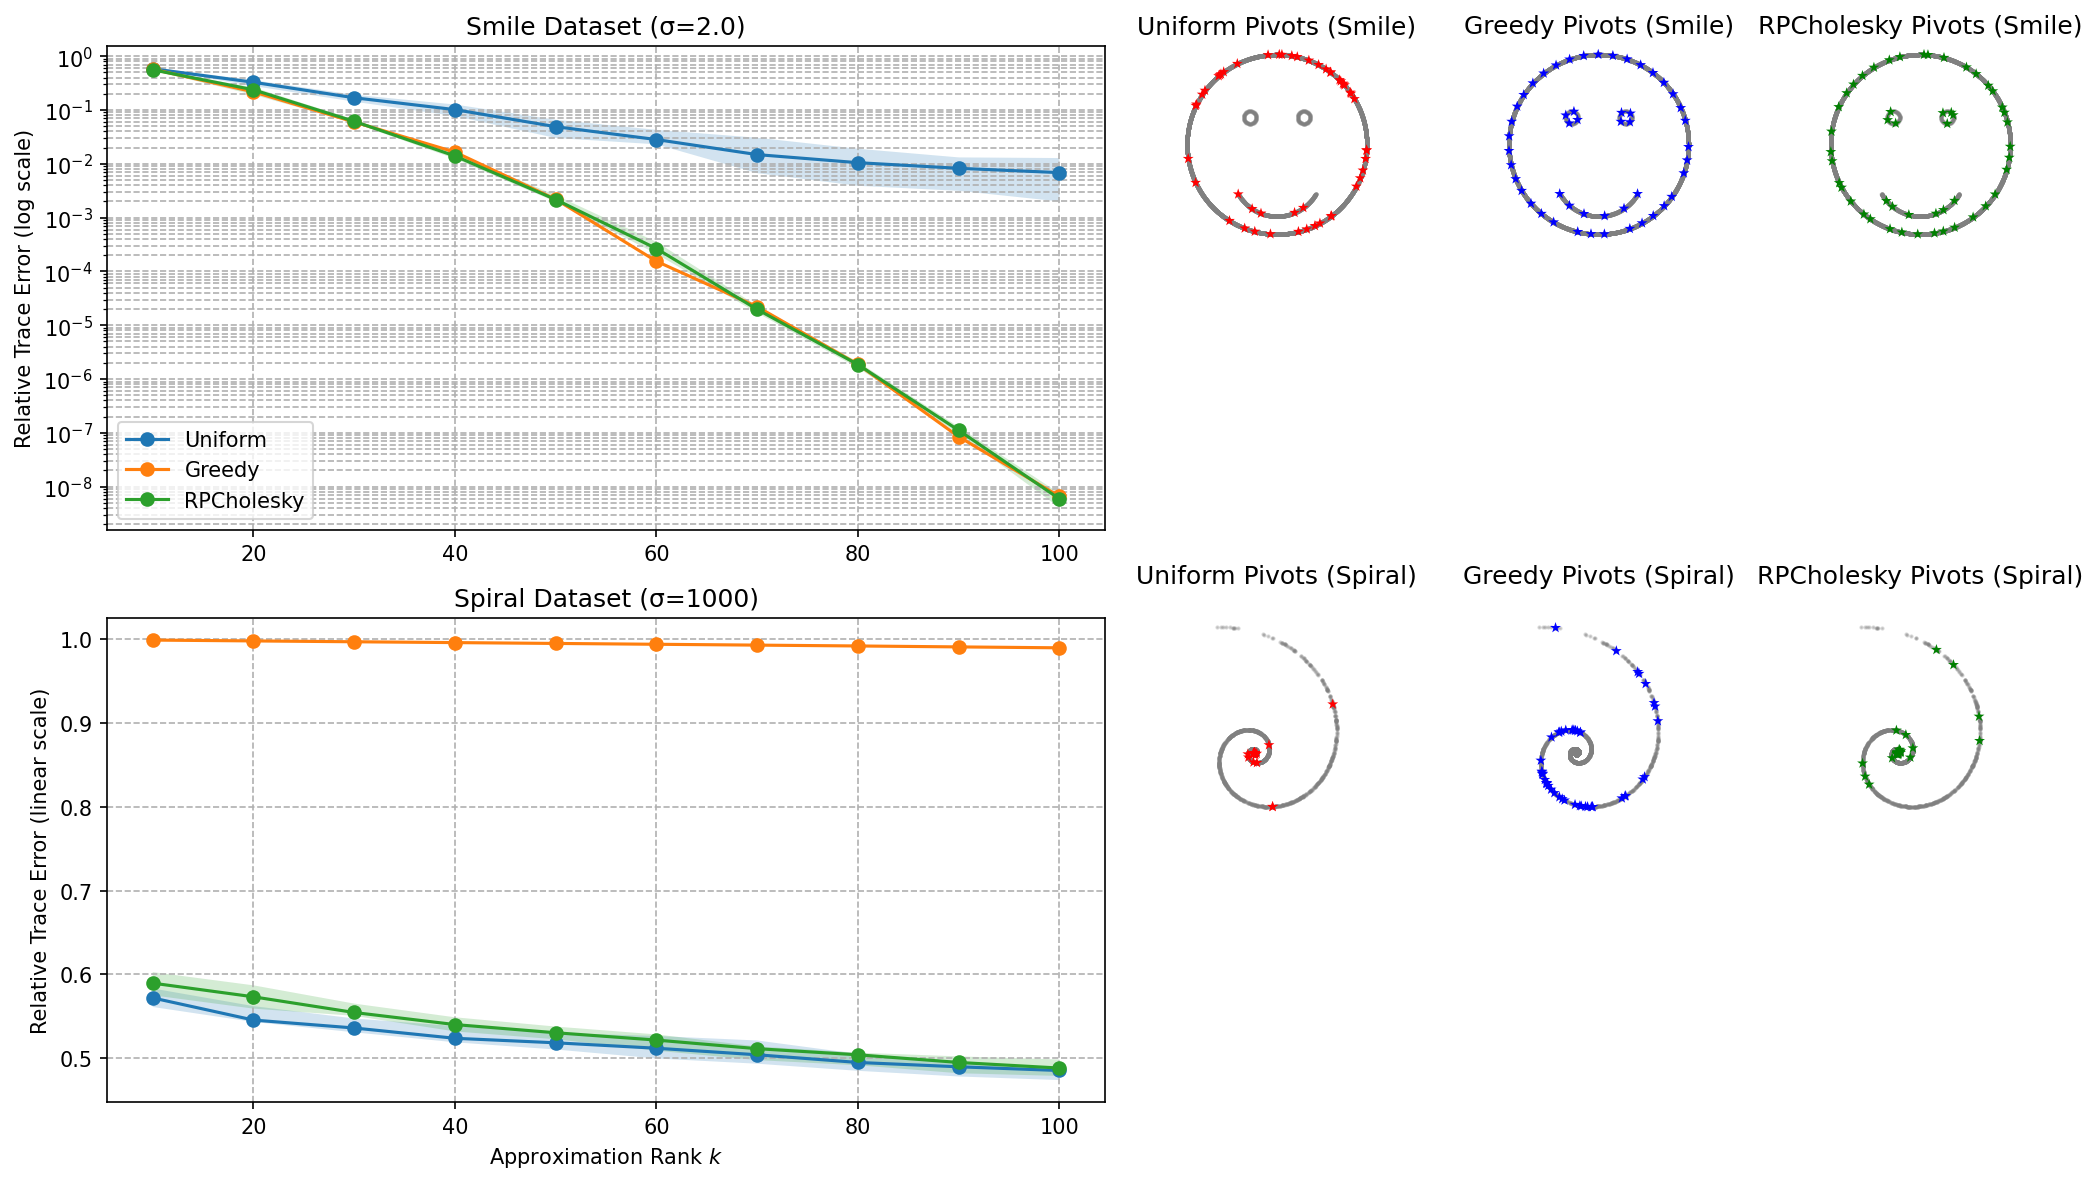

In [44]:
def run_trials(X, sigma, max_k=100, n_trials=20):
    A = gaussian_kernel(X, sigma)
    methods = {
        "RPCholesky": rpcholesky,
        "Greedy": greedy_pivoted_cholesky,
        "Uniform": uniform_pivoted_cholesky
    }
    
    k_steps = list(range(10, max_k + 1, 10))
    error_stats = {name: np.zeros((len(k_steps), n_trials)) for name in methods}
    pivot_examples = {name: [] for name in methods}

    for trial in range(n_trials):
        for name, method in methods.items():
            S, F = method(A, max_k)
            
            for idx, k in enumerate(k_steps):
                A_hat = F[:, :k] @ F[:, :k].T.conj()
                error_stats[name][idx, trial] = np.trace(A - A_hat) / np.trace(A)
                
            if trial == n_trials - 1:
                pivot_examples[name] = S  # Store pivot indices

    results = {}
    for name in methods:
        median = np.median(error_stats[name], axis=1)
        q20 = np.percentile(error_stats[name], 20, axis=1)
        q80 = np.percentile(error_stats[name], 80, axis=1)
        results[name] = (median, q20, q80)
    
    return results, pivot_examples

# =============================================
# 5. Visualization with Semi-Log Plots
# =============================================

def plot_pivots(data, pivots, ax):
    ax.scatter(data[:, 0], data[:, 1], s=1, c='gray', alpha=0.3)
    colors = {'Uniform': 'red', 'Greedy': 'blue', 'RPCholesky': 'green'}
    for name in pivots:
        idxs = pivots[name][:50]  # First 50 pivots
        ax.scatter(data[idxs, 0], data[idxs, 1], 
                   s=50, marker='*', edgecolor='k',
                   label=name, c=colors[name])
    ax.axis('equal')
    ax.legend()

def create_figure(smile_results, smile_pivots, spiral_results, spiral_pivots):
    fig = plt.figure(figsize=(14, 8), dpi=150)
    gs = GridSpec(4, 4, width_ratios=[1, 0.3, 0.3, 0.3], height_ratios=[1, 1, 1, 1])
    
    # -----------------------------------------
    # Error Plots
    # -----------------------------------------
    # Smile (log scale)
    ax_smile = fig.add_subplot(gs[0:2, 0])
    k_range = np.arange(10, 101, 10)
    for name in ["Uniform", "Greedy", "RPCholesky"]:
        mean, q20, q80 = smile_results[name]
        ax_smile.plot(k_range, mean, 'o-', label=name)
        ax_smile.fill_between(k_range, q20, q80, alpha=0.2)
    ax_smile.set_yscale('log')
    ax_smile.set_title("Smile Dataset (σ=2.0)")
    ax_smile.set_ylabel("Relative Trace Error (log scale)")
    ax_smile.grid(True, which='both', ls='--')
    ax_smile.legend()
    
    # Spiral (linear scale)
    ax_spiral = fig.add_subplot(gs[2:4, 0])
    for name in ["Uniform", "Greedy", "RPCholesky"]:
        mean, q20, q80 = spiral_results[name]
        ax_spiral.plot(k_range, mean, 'o-', label=name)
        ax_spiral.fill_between(k_range, q20, q80, alpha=0.2)
    ax_spiral.set_title("Spiral Dataset (σ=1000)")
    ax_spiral.set_xlabel("Approximation Rank $k$")
    ax_spiral.set_ylabel("Relative Trace Error (linear scale)")
    ax_spiral.grid(True, ls='--')

    # -----------------------------------------
    # Pivot Visualization (Separate Subplots)
    # -----------------------------------------
    colors = {'Uniform': 'red', 'Greedy': 'blue', 'RPCholesky': 'green'}
    
    # Smile Pivots
    for col, name in enumerate(["Uniform", "Greedy", "RPCholesky"], start=1):
        ax = fig.add_subplot(gs[0, col])
        ax.scatter(smile_data[:, 0], smile_data[:, 1], s=1, c='gray', alpha=0.3)
        idxs = smile_pivots[name][:50]
        ax.scatter(smile_data[idxs, 0], smile_data[idxs, 1], 
                   s=30, marker='*', edgecolor='none', c=colors[name])  # No edge color
        ax.set_title(f"{name} Pivots (Smile)")
        ax.axis('equal')
        ax.axis('off')
    
    # Spiral Pivots
    for col, name in enumerate(["Uniform", "Greedy", "RPCholesky"], start=1):
        ax = fig.add_subplot(gs[2, col])
        ax.scatter(spiral_data[:, 0], spiral_data[:, 1], s=1, c='gray', alpha=0.3)
        idxs = spiral_pivots[name][:50]
        ax.scatter(spiral_data[idxs, 0], spiral_data[idxs, 1], 
                   s=30, marker='*', edgecolor='none', c=colors[name])  # No edge color
        ax.set_title(f"{name} Pivots (Spiral)")
        ax.axis('equal')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('final_comparison_updated.png', bbox_inches='tight')
    plt.show()

# =============================================
# 6. Main Execution
# =============================================

if __name__ == "__main__":
    # Run experiments
    smile_results, smile_pivots = run_trials(smile_data, sigma=2.0, n_trials=10)
    spiral_results, spiral_pivots = run_trials(spiral_data, sigma=1000, n_trials=10)
    
    # Create final figure
    create_figure(smile_results, smile_pivots, spiral_results, spiral_pivots)

# Kernel Ridge Regression for QM9 Data---Predicting HOMO Energy  

CSV Data Preview:
   mol_id smiles          A           B           C      mu  alpha    homo  \
0  gdb_1      C  157.71180  157.709970  157.706990  0.0000  13.21 -0.3877   
1  gdb_2      N  293.60975  293.541110  191.393970  1.6256   9.46 -0.2570   
2  gdb_3      O  799.58812  437.903860  282.945450  1.8511   6.31 -0.2928   
3  gdb_4    C#C    0.00000   35.610036   35.610036  0.0000  16.28 -0.2845   
4  gdb_5    C#N    0.00000   44.593883   44.593883  2.8937  12.99 -0.3604   

     lumo     gap  ...      zpve         u0       u298       h298       g298  \
0  0.1171  0.5048  ...  0.044749 -40.478930 -40.476062 -40.475117 -40.498597   
1  0.0829  0.3399  ...  0.034358 -56.525887 -56.523026 -56.522082 -56.544961   
2  0.0687  0.3615  ...  0.021375 -76.404702 -76.401867 -76.400922 -76.422349   
3  0.0506  0.3351  ...  0.026841 -77.308427 -77.305527 -77.304583 -77.327429   
4  0.0191  0.3796  ...  0.016601 -93.411888 -93.409370 -93.408425 -93.431246   

      cv     u0_atom   u298_atom   h2

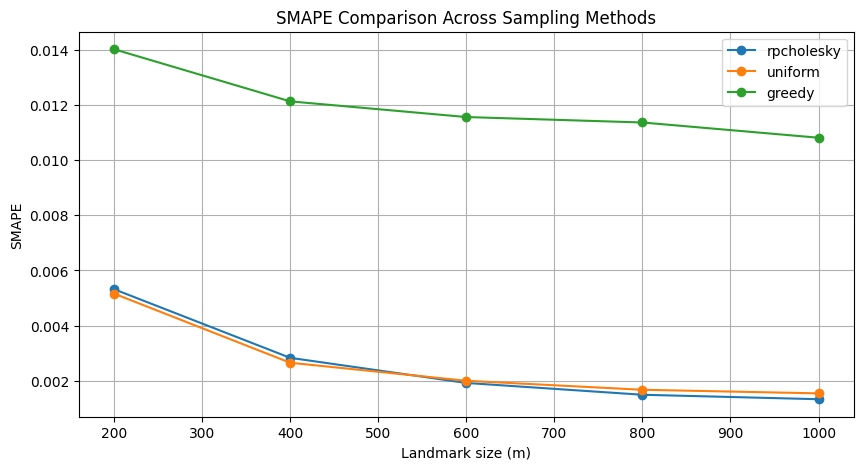

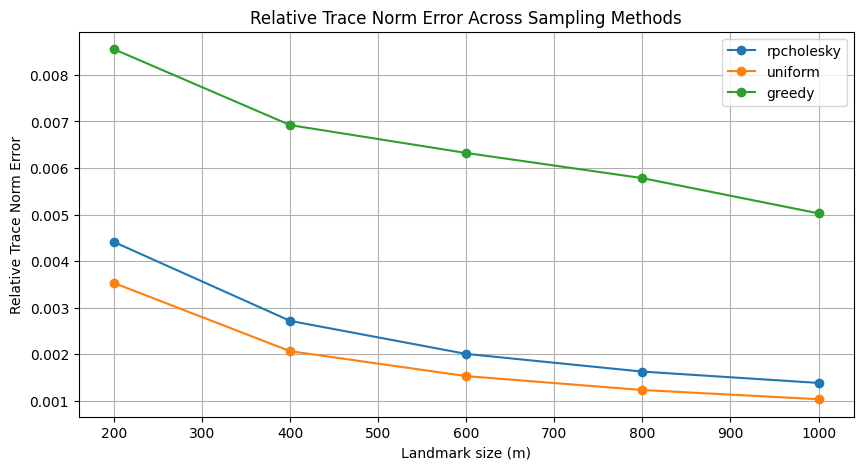

In [5]:
"""
QM9 KRR via Nystrom (using QMlib) with Custom Sampling Methods
--------------------------------------------------------------------------
This script applies (`uniform_pivoted_cholesky`, 
`greedy_pivoted_cholesky`, and `rpcholesky`) to Nystrom-based Kernel Ridge Regression.

### CSV File Assumptions:
- Located at `/Users/zhenyuhong/qm9.csv`
- Contains **only numeric columns** (or non-numeric columns have been dropped).
- All columns **except the last** are features; **last column** is the target property.

### Key Parameters:
- **Laplacian kernel bandwidth** (`sigma`) = `5120.0`  
- **Regularization parameter** (`lambda`) = `1e-8`  
- Uses different **sampling strategies** for selecting Nystrom landmarks.

### Outputs:
- Compares **SMAPE across sampling methods**
- **Plots relative trace norm error** per method.
"""


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from qmllib.kernels import laplacian_kernel


# --- Load CSV Data ---
def load_qm9_csv(filepath):
    """
    Loads QM9 data from a CSV file, ensuring only numeric columns are used.
    """
    data = pd.read_csv(filepath)
    print("CSV Data Preview:\n", data.head())

    # Select only numeric columns (drop strings or categorical data)
    numeric_data = data.select_dtypes(include=["number"])
    if numeric_data.shape[1] == 0:
        raise ValueError("No numeric columns found in the CSV file.")

    print("Numeric columns found:", numeric_data.columns.tolist())

    # Assume all but the last column are features; last column is the target.
    features = numeric_data.iloc[:, :-1].to_numpy()
    target   = numeric_data.iloc[:, -1].to_numpy()
    return features, target

# --- Nystrom Approximation ---
def nystrom_KRR(train_X, train_y, sigma, lamb, m, sample_method="uniform"):
    """
    Scalable Nystrom KRR with correct regularization and trace error.
    Avoids full kernel matrix for large datasets.
    """
    n = train_X.shape[0]

    # Select landmarks using specified method (without full kernel matrix)
    if sample_method == "uniform":
        landmark_idx = np.random.choice(n, size=m, replace=False)
    elif sample_method == "greedy":
        # Greedy selection using diagonal elements only
        diag = np.array([laplacian_kernel(x.reshape(1,-1), x.reshape(1,-1), sigma) 
                        for x in train_X]).flatten()
        landmark_idx = np.argpartition(-diag, m)[:m]
    elif sample_method == "rpcholesky":
        # For demonstration - this still needs full kernel matrix
        K = laplacian_kernel(train_X, train_X, sigma)
        landmark_idx, _ = rpcholesky(K, m)
    else:
        raise ValueError("Invalid sampling method")

    landmarks = train_X[landmark_idx]

    # Compute required kernel submatrices
    K_nm = laplacian_kernel(train_X, landmarks, sigma)  # (n, m)
    K_mm = laplacian_kernel(landmarks, landmarks, sigma)  # (m, m)

    # CORRECT REGULARIZATION 
    A = K_nm.T @ K_nm + lamb * K_mm  # No pre-diagonal modification
    b = K_nm.T @ train_y
    
    # Numerically stable solve
    try:
        beta = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        beta = np.linalg.lstsq(A, b, rcond=1e-6)[0]

    # TRACE ERROR COMPUTATION (EFFICIENT)
    trace_K_nn = n  # Sum of Laplacian diagonals (all 1s)
    K_mm_inv = np.linalg.pinv(K_mm)
    K_approx_diag = np.einsum("ij,jk,ik->i", K_nm, K_mm_inv, K_nm)
    trace_error = abs(trace_K_nn - np.sum(K_approx_diag)) / trace_K_nn

    return beta, landmarks, trace_error



# --- Prediction Function ---
def predict_nystrom(test_X, landmarks, sigma, beta):
    """
    Predicts values using a **Nystrom approximation**.
    """
    K_test = laplacian_kernel(test_X, landmarks, sigma)
    return np.dot(K_test, beta)

# --- Evaluation Metrics ---
def mean_squared_error(true, pred):
    return np.mean((true - pred) ** 2)

def mean_absolute_error(true, pred):
    return np.mean(np.abs(true - pred))

def SMAPE(true, pred):
    return np.mean(np.abs(true - pred) / ((np.abs(true) + np.abs(pred)) / 2))

# --- Main Function ---
def main():
    # Load CSV
    csv_path = '/Users/zhenyuhong/qm9.csv'
    features, target = load_qm9_csv(csv_path)
    
    # Standardize features
    scaler = StandardScaler()
    features = scaler.fit_transform(features)

    # Split dataset: 80% training, 20% testing
    n_samples = features.shape[0]
    num_train = int(0.8 * n_samples)
    train_X, train_y = features[:num_train], target[:num_train]
    test_X, test_y = features[num_train:], target[num_train:]

    print(f"Training Samples: {train_X.shape[0]}, Testing Samples: {test_X.shape[0]}")

    # KRR Hyperparameters
    sigma = 512.0   # Kernel bandwidth
    lamb = 1e-8      # Regularization parameter
    landmark_sizes = [200, 400, 600, 800, 1000]
    num_trials = 10  # Number of trials per landmark size

    methods = ["rpcholesky","uniform", "greedy"]
    results = {method: {} for method in methods}
    trace_errors = {method: [] for method in methods}

    # Loop over methods
    for method in methods:
        print(f"\nMethod: {method.upper()}")
        for m in landmark_sizes:
            mse_list, mae_list, smape_list, trace_error_list = [], [], [], []
            print(f"Landmark size: {m}")

            for i in range(num_trials):
                beta, landmarks, trace_error = nystrom_KRR(train_X, train_y, sigma, lamb, m, method)
                pred = predict_nystrom(test_X, landmarks, sigma, beta)

                mse_list.append(mean_squared_error(test_y, pred))
                mae_list.append(mean_absolute_error(test_y, pred))
                smape_list.append(SMAPE(test_y, pred))
                trace_error_list.append(trace_error)
                
                print(f"Trial {i}: MSE={mse_list[-1]:.4f}, MAE={mae_list[-1]:.4f}, SMAPE={smape_list[-1]:.4f}, TraceErr={trace_error:.4f}")

            results[method][str(m)] = {
                "MSE_mean": np.mean(mse_list),
                "MAE_mean": np.mean(mae_list),
                "SMAPE_mean": np.mean(smape_list),
            }
            trace_errors[method].append(np.mean(trace_error_list))

    # --- Plot SMAPE Comparison ---
    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(landmark_sizes, [results[method][str(m)]["SMAPE_mean"] for m in landmark_sizes], 'o-', label=method)
    plt.xlabel("Landmark size (m)")
    plt.ylabel("SMAPE")
    plt.title("SMAPE Comparison Across Sampling Methods")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot Relative Trace Norm Error ---
    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(landmark_sizes, trace_errors[method], 'o-', label=method)
    plt.xlabel("Landmark size (m)")
    plt.ylabel("Relative Trace Norm Error")
    plt.title("Relative Trace Norm Error Across Sampling Methods")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()
